In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/wine-dataset-for-clustering/wine-clustering.csv


In [3]:
# Read the dataset

df = pd.read_csv('/kaggle/input/wine-dataset-for-clustering/wine-clustering.csv')
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.columns

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')

In [5]:
df.shape

(178, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic_Acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Ash_Alcanity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_Phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_Intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [8]:
# Make a sub data frame for feature scaling

columns_to_scale = ['Alcohol', 'Ash_Alcanity', 'Magnesium', 'Proline']
df_sub = df[columns_to_scale]
df_sub.head()

,Alcohol,Ash_Alcanity,Magnesium,Proline
0,14.23,15.6,127,1065
1,13.20,11.2,100,1050
2,13.16,18.6,101,1185
3,14.37,16.8,113,1480
4,13.24,21.0,118,735


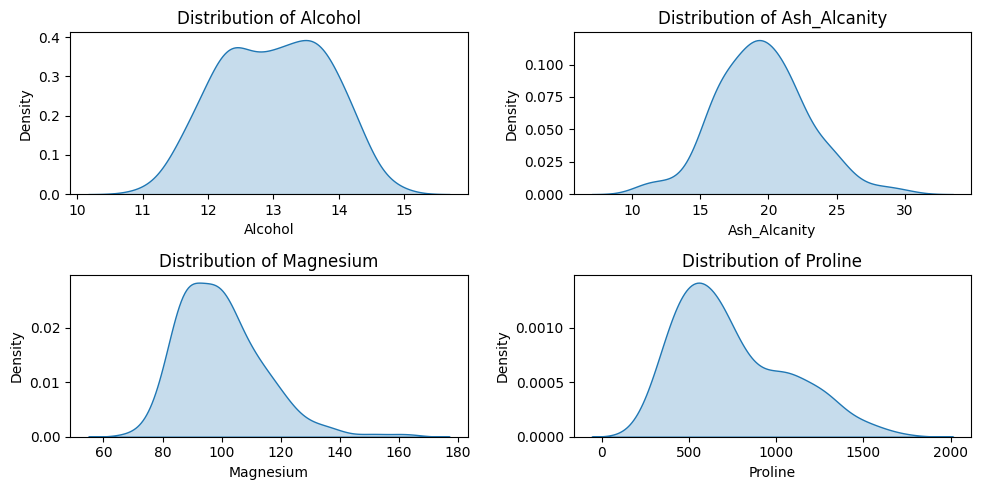

In [9]:
# Show the distribution of each column

plt.figure(figsize=(10, 5))

for i in range(len(columns_to_scale)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x = df_sub[columns_to_scale[i]], data = df_sub, fill='blue')
    plt.title(f"Distribution of {columns_to_scale[i]}")

plt.tight_layout()
plt.show()

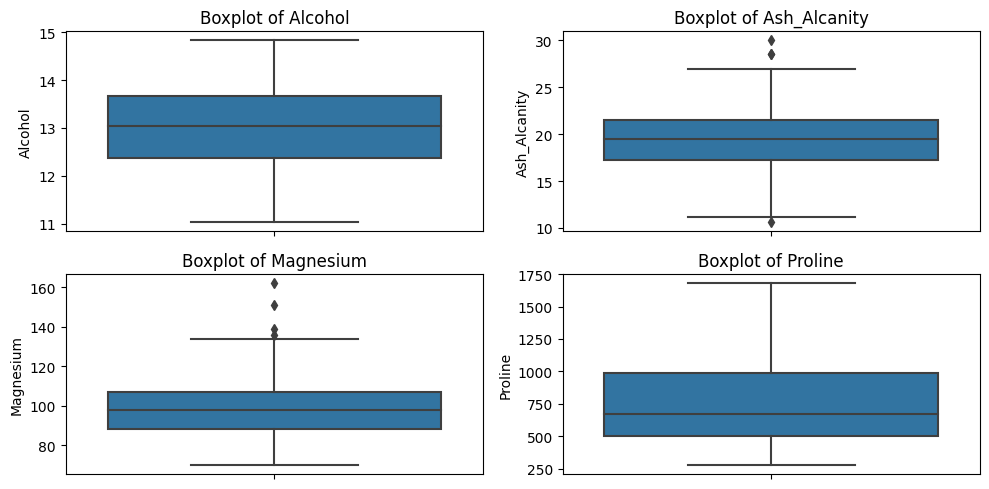

In [10]:
# Check for outliers in df_sub

plt.figure(figsize=(10, 5))

for i in range(len(columns_to_scale)):
    plt.subplot(2, 2, i+1)
    sns.boxplot(y=df_sub[columns_to_scale[i]], data=df_sub)
    plt.title(f"Boxplot of {columns_to_scale[i]}")

plt.tight_layout()
plt.show()

In [11]:
# Because of outliers we should use Robust Scaler!

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled_data = scaler.fit_transform(df_sub)

scaled_df = pd.DataFrame(scaled_data, columns = df_sub.columns)
scaled_df.head()

,Alcohol,Ash_Alcanity,Magnesium,Proline
0,0.897338,-0.906977,1.526316,0.808050
1,0.114068,-1.930233,0.105263,0.777090
2,0.083650,-0.209302,0.157895,1.055728
3,1.003802,-0.627907,0.789474,1.664603
4,0.144487,0.348837,1.052632,0.126935


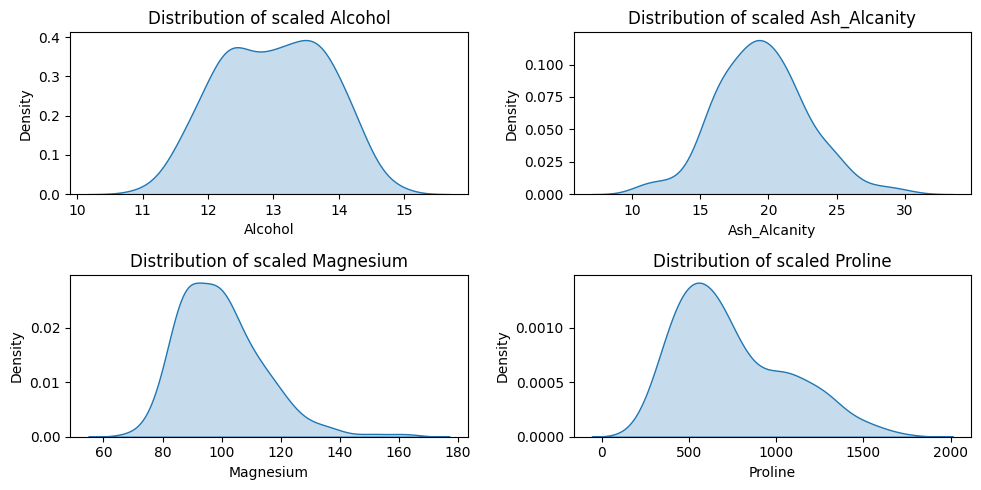

In [12]:
plt.figure(figsize=(10, 5))

for i in range(len(columns_to_scale)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df_sub[columns_to_scale[i]], data=df_sub, fill='blue')
    plt.title(f"Distribution of scaled {columns_to_scale[i]}")

plt.tight_layout()
plt.show()